# LOGISTIC REGRESSION

In [60]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

class OwnLogistic:
    def __init__(self,lr,epochs):
        self.lr=lr
        self.epochs=epochs
        self.weights=None

    def fit(self,X_train,y_train):
        self.X_train=np.insert(X_train,0,1,axis=1)
        self.weights=np.ones(self.X_train.shape[1])

        for i in range(self.epochs):
            y_hat=self.sigmoid(np.dot(self.X_train,self.weights))
            self.weights=self.weights+(self.lr*(np.dot((y_train-y_hat),self.X_train)))/self.X_train.shape[0]
        return self.weights[0], self.weights[1:]

    def predict(self,X_test):
        self.X_test=np.insert(X_test,0,1,axis=1)
        probs=self.sigmoid(np.dot(self.X_test,self.weights))
        return np.where(probs>0.5,1,0)

    def sigmoid(self,z):
        return 1/(1+np.exp(-z))
        
        
X,y=make_classification(n_samples=500,
                        n_features=2,
                        n_informative=1,
                        n_redundant=0,
                        n_classes=2,
                        n_clusters_per_class=1,
                        hypercube=False,
                        random_state=103,
                        class_sep=10)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

LR=LogisticRegression(penalty=None,max_iter=5000)
LR.fit(X_train,y_train)
y_pred1=LR.predict(X_test)

own_LR=OwnLogistic(lr=0.01,epochs=5000)
intercept_,coef_=own_LR.fit(X_train,y_train)
y_pred2=own_LR.predict(X_test)

print(confusion_matrix(y_test,y_pred1))
print(classification_report(y_test,y_pred1))

[[51  0]
 [ 0 49]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        51
           1       1.00      1.00      1.00        49

    accuracy                           1.00       100
   macro avg       1.00      1.00      1.00       100
weighted avg       1.00      1.00      1.00       100



In [61]:
slope_LR=-(LR.coef_[0][0]/LR.coef_[0][1])
intercept_LR=-(LR.intercept_/LR.coef_[0][1])\

ownslope_LR=-(coef_[0]/coef_[1])
ownintercept_LR=-(intercept_/coef_[1])

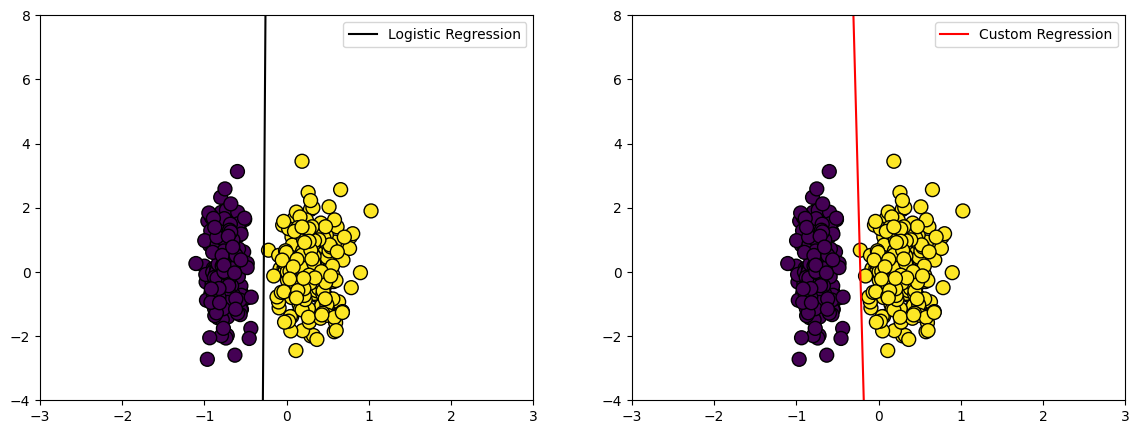

In [62]:
plt.figure(figsize=(14,5))

plt.subplot(1,2,1)           
x_input=np.linspace(-3,3,100)
y_input=slope_LR*x_input+intercept_LR
plt.plot(x_input,y_input,color='black',label='Logistic Regression')
plt.scatter(X[:,0],X[:,1],c=y,cmap='viridis',s=100,edgecolor='k')
plt.xlim(-3,3)
plt.ylim(-4,8)
plt.legend()

plt.subplot(1,2,2)           
y_input=ownslope_LR*x_input+ownintercept_LR
plt.plot(x_input,y_input,color='red',label='Custom Regression')
plt.scatter(X[:,0],X[:,1],c=y,cmap='viridis',s=100,edgecolor='k')
plt.xlim(-3,3)
plt.ylim(-4,8)
plt.legend()

In [63]:
print("Sklearn")
print(LR.intercept_)
print(LR.coef_)

print("\nCustom")
print(intercept_)
print(coef_)

Sklearn
[3.29997293]
[[11.82052649 -0.03093205]]

Custom
1.0492305622150362
[4.74202933 0.04970783]


# SOFTMAX MULTICLASS

In [66]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

class Softmax:
    def __init__(self,lr,epochs):
        self.lr=lr
        self.epochs=epochs
        self.weights=None
        
    def fit(self,X_train,y_train):
        self.X_train=np.insert(X_train,0,1,axis=1)
        self.weights=np.zeros((self.X_train.shape[1],y_train.shape[1]))

        for i in range(self.epochs):
            y_hat=self.softmax(np.dot(self.X_train,self.weights))
            self.weights=self.weights+(self.lr*np.dot(self.X_train.T,(y_train-y_hat)))/self.X_train.shape[0]
        return self.weights[0], self.weights[1:,:]
        
    def predict(self, X_test):
        self.X_test=np.insert(X_test,0,1,axis=1)
        probs=self.softmax(np.dot(self.X_test,self.weights))
        return np.argmax(probs, axis=1)
        
    def softmax(self,z):
        exp_z=np.exp(z-np.max(z,axis=1,keepdims=True))
        return exp_z/np.sum(exp_z, axis=1, keepdims=True)
        
X,y=load_iris(return_X_y=True)
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
y_train_encoded=pd.get_dummies(y_train,dtype=np.int32).values
y_test_encoded=pd.get_dummies(y_test,dtype=np.int32).values

soft=Softmax(lr=0.01,epochs=5000)
intercept_,coef_=soft.fit(X_train,y_train_encoded)
y_pred=soft.predict(X_test)
y_true=np.argmax(y_test_encoded,axis=1)

print(confusion_matrix(y_true,y_pred))
print("Softmax: \n",classification_report(y_true,y_pred))

print(f"Soft_Intercept: {intercept_}")
print(f"Soft_Coefficient:\n {coef_}")

print("---------------------------------------------------------------------------------------------")

log=LogisticRegression(max_iter=5000)
log.fit(X_train,y_train)
y_pred2=log.predict(X_test)

print(confusion_matrix(y_true,y_pred))
print("Logistic Regression: \n",classification_report(y_true,y_pred))

print(f"Log_Intercept: {intercept_}")
print(f"Log_Coefficient:\n {coef_}")

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Softmax: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Soft_Intercept: [ 0.32582058  0.37731611 -0.70313669]
Soft_Coefficient:
 [[ 0.65718083  0.56289558 -1.22007641]
 [ 1.63916845 -0.22465263 -1.41451582]
 [-2.22900831 -0.07932181  2.30833012]
 [-1.01371941 -0.68895347  1.70267288]]
---------------------------------------------------------------------------------------------
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Logistic Regression: 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00 

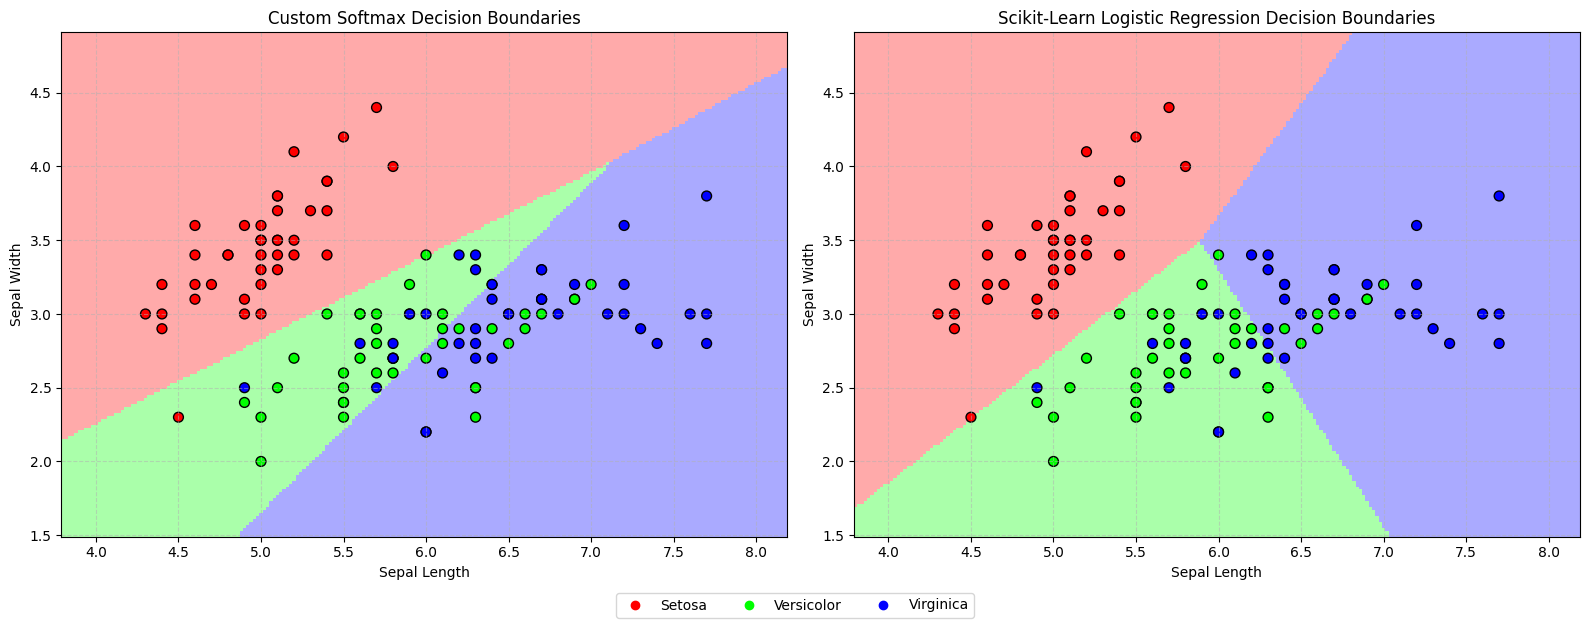

In [67]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

X, y = load_iris(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_2d = X_train[:, :2]
y_train_encoded = pd.get_dummies(y_train, dtype=np.int32).values

soft_visual = Softmax(lr=0.01, epochs=5000)
soft_visual.fit(X_train_2d, y_train_encoded)

log_visual = LogisticRegression(max_iter=5000)
log_visual.fit(X_train_2d, y_train)

x_min, x_max = X_train_2d[:, 0].min() - 0.5, X_train_2d[:, 0].max() + 0.5
y_min, y_max = X_train_2d[:, 1].min() - 0.5, X_train_2d[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
mesh_points = np.c_[xx.ravel(), yy.ravel()]

Z_soft = soft_visual.predict(mesh_points).reshape(xx.shape)
Z_log = log_visual.predict(mesh_points).reshape(xx.shape)

cmap_light = ListedColormap(['#FFAAAA', '#AAFFAA', '#AAAAFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.pcolormesh(xx, yy, Z_soft, cmap=cmap_light, shading='auto')
scatter1 = ax1.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap=cmap_bold, edgecolor='k', s=50)
ax1.set_xlabel('Sepal Length')
ax1.set_ylabel('Sepal Width')
ax1.set_title('Custom Softmax Decision Boundaries')
ax1.grid(True, linestyle='--', alpha=0.5)

ax2.pcolormesh(xx, yy, Z_log, cmap=cmap_light, shading='auto')
scatter2 = ax2.scatter(X_train_2d[:, 0], X_train_2d[:, 1], c=y_train, cmap=cmap_bold, edgecolor='k', s=50)
ax2.set_xlabel('Sepal Length')
ax2.set_ylabel('Sepal Width')
ax2.set_title('Scikit-Learn Logistic Regression Decision Boundaries')
ax2.grid(True, linestyle='--', alpha=0.5)

fig.legend(handles=scatter1.legend_elements()[0], labels=['Setosa', 'Versicolor', 'Virginica'], loc='lower center', ncol=3, bbox_to_anchor=(0.5, -0.05))
plt.tight_layout()
plt.show()